In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [2]:
df = pd.read_csv("Leaf.csv")

In [3]:
print("Data shape:", df.shape)
print(df.head())
print(df.info())

Data shape: (600, 21)
   ID LED    Band_A    Band_B    Band_C    Band_D    Band_E    Band_F  \
0   1   R  0.289823  0.149103  0.837108  0.536785  1.816548  3.308998   
1   2   G  0.184209  0.464555  0.887856  0.684899  3.098814  3.963086   
2   3   B  0.117774  0.469227  0.924004  0.381750  1.660072  2.055483   
3   4   R  0.151149  0.315475  0.861908  0.471856  1.502907  2.793849   
4   5   G  0.179780  0.171641  0.897170  0.593373  1.902586  4.021104   

     Band_G    Band_H  ...    Band_J    Band_K    Band_L  Band_R  Band_S  \
0  4.065359  1.615062  ...  0.454568  0.530174  0.512485     NaN     NaN   
1  5.876332  1.240071  ...  0.220148  0.276886  0.198628     NaN     NaN   
2  2.504755  0.671107  ...  0.214840  0.207288  0.015977     NaN     NaN   
3  3.263187  1.337515  ...  0.290541  0.548673  0.379681     NaN     NaN   
4  5.370995  1.473132  ...  0.399776  0.085026  0.147255     NaN     NaN   

   Band_T  Band_U  Band_V  Band_W  Condition  
0     NaN     NaN     NaN     NaN  

In [4]:
df = df.replace("null", np.nan)

In [5]:
df = df.drop(columns=["ID"])

In [6]:
core_bands = [f"Band_{c}" for c in list("ABCDEFGHIJKL")]
extra_bands = [f"Band_{c}" for c in list("RSTUVW")]

In [7]:
df = df.drop(columns=[c for c in extra_bands if c in df.columns], errors="ignore")

In [8]:
for c in core_bands:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [9]:
band_cols = [col for col in df.columns if col.startswith("Band_")]
df[band_cols] = df[band_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

In [10]:
print("\nSummary statistics:")
print(df.groupby("Condition")[band_cols].mean())


Summary statistics:
             Band_A    Band_B    Band_C    Band_D    Band_E    Band_F  \
Condition                                                               
Healthy    0.255509  0.263878  0.309634  0.332236  0.235981  0.289677   
Turning    0.361431  0.406453  0.397726  0.472412  0.350141  0.349514   
Unhealthy  0.495588  0.559776  0.476219  0.614985  0.467561  0.413430   

             Band_G    Band_H    Band_I    Band_J    Band_K    Band_L  
Condition                                                              
Healthy    0.320569  0.336677  0.370117  0.374571  0.379395  0.403530  
Turning    0.364165  0.401290  0.405899  0.409864  0.398935  0.392627  
Unhealthy  0.406842  0.483945  0.463314  0.433421  0.396214  0.374509  


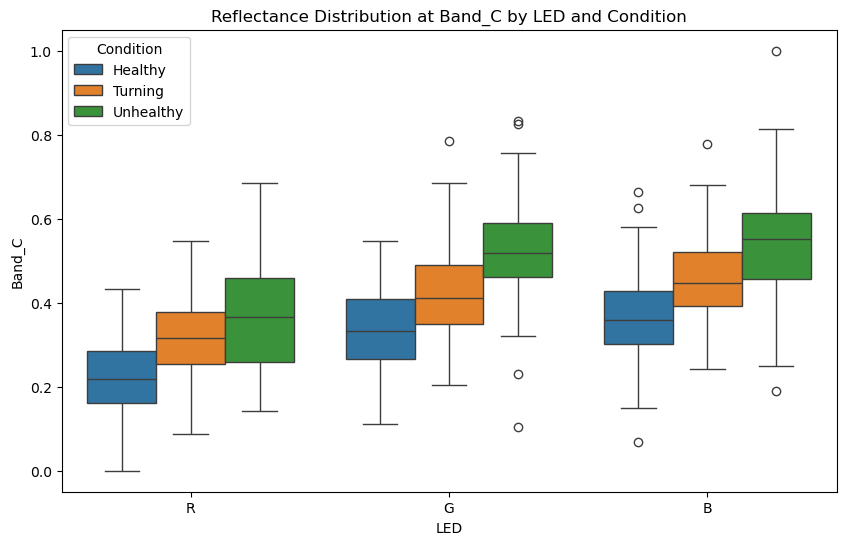

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="LED", y="Band_C", hue="Condition")
plt.title("Reflectance Distribution at Band_C by LED and Condition")
plt.show()

In [12]:
led_encoder = LabelEncoder()
df["LED"] = led_encoder.fit_transform(df["LED"])
target_encoder = LabelEncoder()
df["Condition"] = target_encoder.fit_transform(df["Condition"])
print("LED mapping:", dict(zip(led_encoder.classes_, led_encoder.transform(led_encoder.classes_))))
print("Condition mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

LED mapping: {'B': 0, 'G': 1, 'R': 2}
Condition mapping: {'Healthy': 0, 'Turning': 1, 'Unhealthy': 2}


In [13]:
X = df.drop("Condition", axis=1)
y = df["Condition"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (480, 13)
Testing set size: (120, 13)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

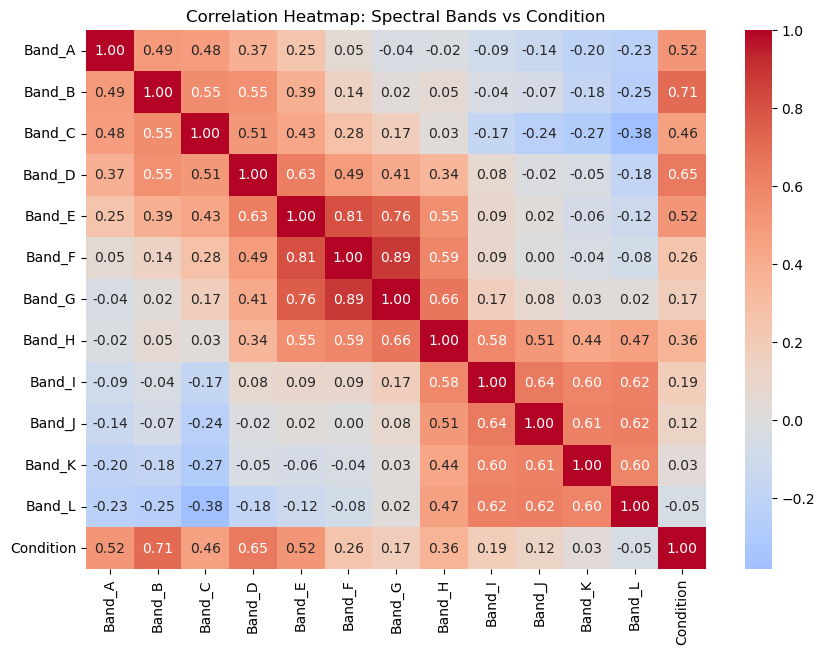


Correlation of each band with target (Condition=Yellow=1):

Band_B    0.705939
Band_D    0.645409
Band_E    0.521615
Band_A    0.516198
Band_C    0.460462
Band_H    0.355525
Band_F    0.258110
Band_I    0.188277
Band_G    0.174202
Band_J    0.124379
Band_K    0.034477
Band_L   -0.052855
Name: Condition, dtype: float64


In [17]:
band_cols = [c for c in df.columns if c.startswith("Band_")]

corr = df[band_cols + ["Condition"]].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap: Spectral Bands vs Condition")
plt.show()

corr_target = corr["Condition"].drop("Condition").sort_values(ascending=False)
print("\nCorrelation of each band with target (Condition=Yellow=1):\n")
print(corr_target)

# Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [21]:
y_pred = dt.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

In [22]:
print("Accuracy:", round(acc, 4))
print("\nClasses:", list(target_encoder.classes_))
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.5917

Classes: ['Healthy', 'Turning', 'Unhealthy']

Confusion matrix:
 [[24 16  0]
 [ 9 21 10]
 [ 0 14 26]]

Classification report:
               precision    recall  f1-score   support

     Healthy       0.73      0.60      0.66        40
     Turning       0.41      0.53      0.46        40
   Unhealthy       0.72      0.65      0.68        40

    accuracy                           0.59       120
   macro avg       0.62      0.59      0.60       120
weighted avg       0.62      0.59      0.60       120



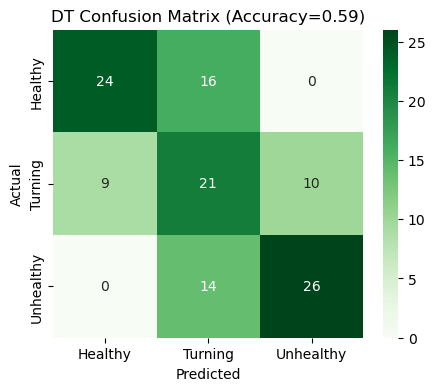

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"DT Confusion Matrix (Accuracy={acc:.2f})")
plt.show()

Top 10 most important features:

Feature  Importance
 Band_B    0.508464
 Band_E    0.153084
 Band_D    0.098289
 Band_H    0.075313
 Band_A    0.066710
 Band_K    0.034722
 Band_C    0.018444
 Band_F    0.014969
 Band_L    0.011889
 Band_G    0.009624


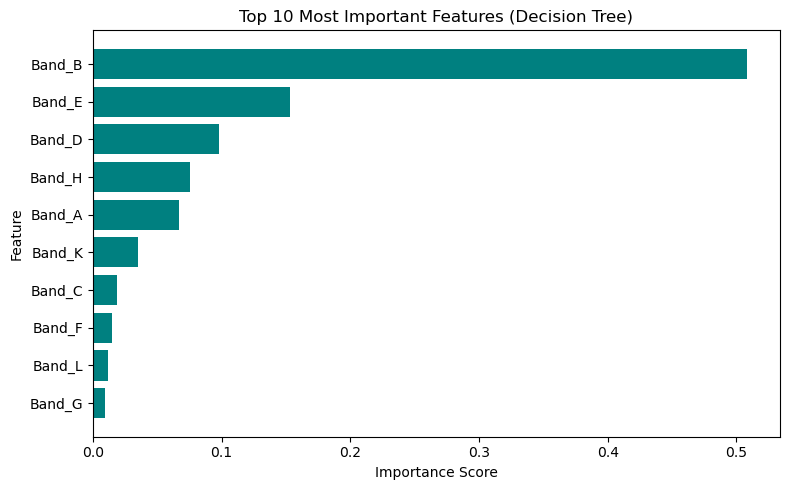

In [26]:
importances = dt.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top10 = feat_imp.head(10)
print("Top 10 most important features:\n")
print(top10.to_string(index=False))

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features (Decision Tree)')
plt.tight_layout()
plt.show()

# SVM

In [28]:
from sklearn.svm import SVC

In [30]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [32]:
y_pred_svm = svm_model.predict(X_test_scaled)
cm  = confusion_matrix(y_test, y_pred)

In [34]:
acc_svm = accuracy_score(y_test, y_pred_svm)
cm_svm  = confusion_matrix(y_test, y_pred_svm)

print(f"SVM Accuracy: {acc_svm:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=target_encoder.classes_))

SVM Accuracy: 0.7833

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.84      0.80      0.82        40
     Turning       0.67      0.70      0.68        40
   Unhealthy       0.85      0.85      0.85        40

    accuracy                           0.78       120
   macro avg       0.79      0.78      0.78       120
weighted avg       0.79      0.78      0.78       120



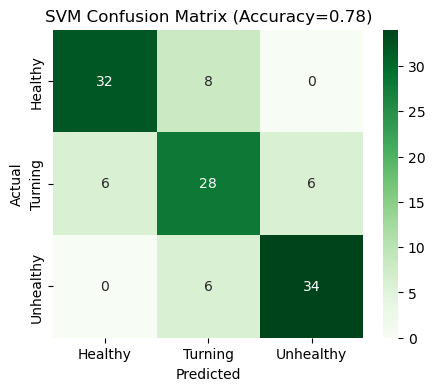

In [36]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"SVM Confusion Matrix (Accuracy={acc_svm:.2f})")
plt.show()

# CNN

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

X_train_np = np.array(X_train_scaled)
X_test_np  = np.array(X_test_scaled)

n_features = X_train_np.shape[1]  # number of input columns
X_train_cnn = X_train_np.reshape(-1, n_features, 1)
X_test_cnn  = X_test_np.reshape(-1, n_features, 1)

num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(n_features, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\shane\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,691 (41.76 KB)

 Trainable params: 10,691 (41.76 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5)

history = model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=100,
    batch_size=16,
    callbacks=[es, rlr],
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4563 - loss: 1.0410 - val_accuracy: 0.5583 - val_loss: 0.9496 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5688 - loss: 0.8963 - val_accuracy: 0.6167 - val_loss: 0.8059 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6083 - loss: 0.8292 - val_accuracy: 0.6417 - val_loss: 0.7438 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6417 - loss: 0.7661 - val_accuracy: 0.6500 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6604 - loss: 0.7266 - val_accuracy: 0.6500 - val_loss: 0.6834 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6750 - loss: 0.7183 - val_accuracy: 0.6750 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6854 - loss: 0.6797 - val_ac

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

CNN Accuracy: 0.758

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81        40
           1       0.65      0.65      0.65        40
           2       0.82      0.80      0.81        40

    accuracy                           0.76       120
   macro avg       0.76      0.76      0.76       120
weighted avg       0.76      0.76      0.76       120



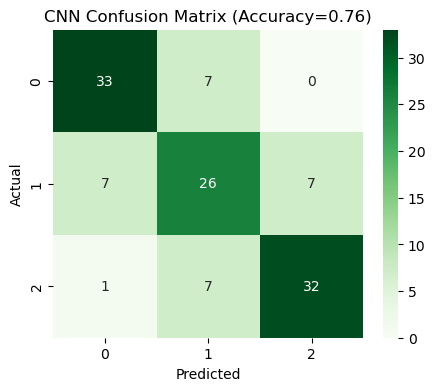

In [41]:
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

acc = accuracy_score(y_true, y_pred)
print(f"\nCNN Accuracy: {acc:.3f}")

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=np.unique(y_train).astype(str)))

# --- 5. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f"CNN Confusion Matrix (Accuracy={acc:.2f})")
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

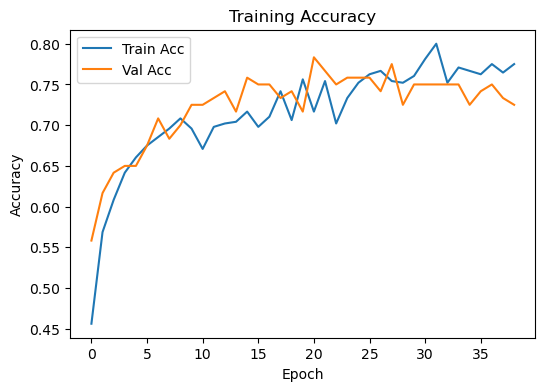

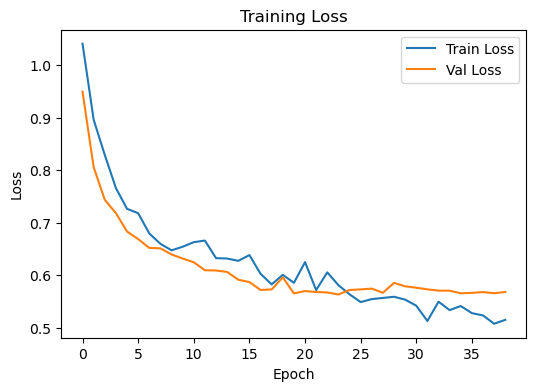

In [42]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

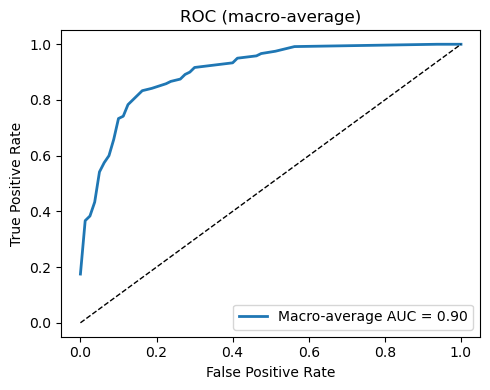

In [43]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# y_test_cat: one-hot true labels (N, num_classes)
# y_pred_probs: predicted probabilities (N, num_classes)

num_classes = y_test_cat.shape[1]

if num_classes == 2:
    # ---- Single ROC (binary)
    fpr, tpr, _ = roc_curve(y_test_cat[:, 1], y_pred_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC (binary)")
    plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

else:
    # ---- Single ROC (multiclass macro-average as one curve)
    # Compute ROC for each class
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Build macro-average curve (average TPR at all unique FPR points)
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= num_classes
    macro_auc = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(5,4))
    plt.plot(all_fpr, mean_tpr, lw=2, label=f"Macro-average AUC = {macro_auc:.2f}")
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC (macro-average)")
    plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()


MLP Accuracy: 0.758

Classification report:
               precision    recall  f1-score   support

     Healthy       0.79      0.85      0.82        40
     Turning       0.68      0.57      0.62        40
   Unhealthy       0.79      0.85      0.82        40

    accuracy                           0.76       120
   macro avg       0.75      0.76      0.75       120
weighted avg       0.75      0.76      0.75       120



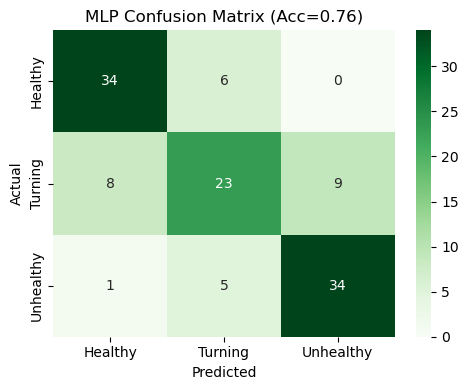

In [44]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,              # L2 regularization
    batch_size=16,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# 2) Evaluate
y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

try:
    class_names = list(target_encoder.classes_)
except:
    class_names = [str(c) for c in sorted(np.unique(y_train))]

print(f"MLP Accuracy: {acc:.3f}\n")
print("Classification report:\n",
      classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"MLP Confusion Matrix (Acc={acc:.2f})")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


# ROC Curve

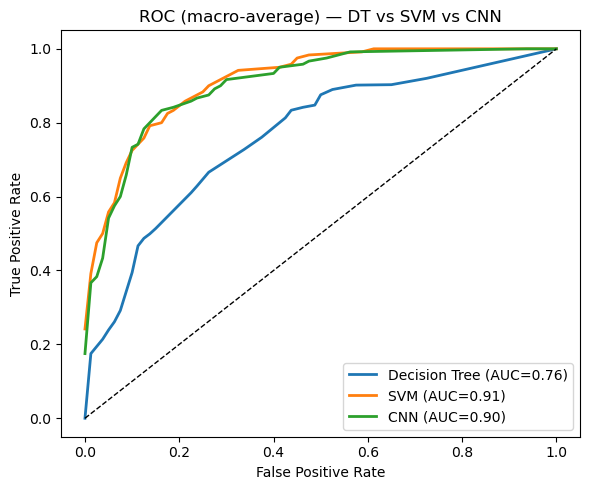

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ---------- 1) Helpers: single macro-average ROC (works for binary or multiclass) ----------
def macro_roc(y_true, proba, num_classes):
    """
    y_true: integer labels shape (N,)
    proba:  predicted probabilities shape (N, C)
    returns fpr_macro, tpr_macro, auc_macro
    """
    # one-hot
    y_true_oh = label_binarize(y_true, classes=np.arange(num_classes))
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true_oh[:, 1], proba[:, 1])
        return fpr, tpr, auc(fpr, tpr)
    # multiclass: macro-average
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_oh[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= num_classes
    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)

# Determine number of classes
num_classes = len(np.unique(y_train))

# ---------- 2) Decision Tree (probabilities) ----------
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
proba_dt = dt.predict_proba(X_test_scaled)
fpr_dt, tpr_dt, auc_dt = macro_roc(y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test, proba_dt, num_classes)

# ---------- 3) SVM with probability=True ----------
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
proba_svm = svm.predict_proba(X_test_scaled)
fpr_svm, tpr_svm, auc_svm = macro_roc(y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test, proba_svm, num_classes)

# ---------- 4) CNN probabilities ----------
# If you already computed y_pred_probs from the CNN, reuse it; otherwise predict now.
try:
    proba_cnn = y_pred_probs
except NameError:
    proba_cnn = model.predict(X_test_cnn)
fpr_cnn, tpr_cnn, auc_cnn = macro_roc(
    (np.argmax(y_test_cat, axis=1) if 'y_test_cat' in globals() else (y_test.to_numpy() if hasattr(y_test,'to_numpy') else y_test)),
    proba_cnn,
    num_classes
)

# ---------- 5) Plot all three on one figure ----------
plt.figure(figsize=(6,5))
plt.plot(fpr_dt,  tpr_dt,  lw=2, label=f"Decision Tree (AUC={auc_dt:.2f})")
plt.plot(fpr_svm, tpr_svm, lw=2, label=f"SVM (AUC={auc_svm:.2f})")
plt.plot(fpr_cnn, tpr_cnn, lw=2, label=f"CNN (AUC={auc_cnn:.2f})")
plt.plot([0,1],[0,1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC (macro-average) — DT vs SVM vs CNN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


C:\Users\shane\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


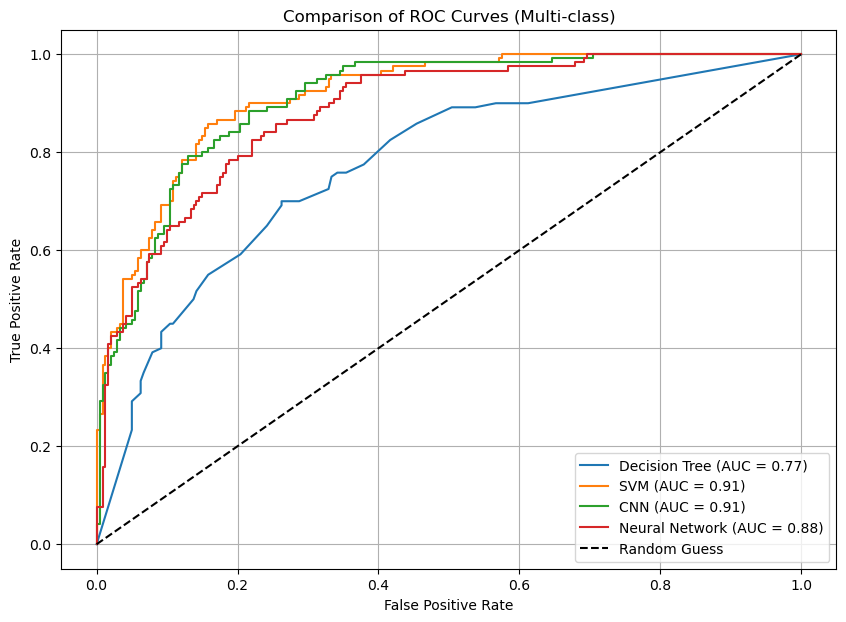

In [47]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# ---------------------- Train Neural Network (MLP) ---------------------
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                    max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_score_mlp = mlp.predict_proba(X_test_scaled)

# ---------------------- Get predictions from DT, SVM, CNN -------------
# DT
y_score_dt = dt.predict_proba(X_test_scaled)

# SVM (need probability=True when creating SVC)
y_score_svm = svm.predict_proba(X_test_scaled)

# CNN (already available as y_pred_probs)
y_score_cnn = y_pred_probs

# ---------------------- Compute ROC-AUC -------------------------------
fpr = dict()
tpr = dict()
roc_auc = {}

model_scores = {
    "Decision Tree": y_score_dt,
    "SVM": y_score_svm,
    "CNN": y_score_cnn,
    "Neural Network": y_score_mlp
}

for model_name, scores in model_scores.items():
    fpr[model_name] = dict()
    tpr[model_name] = dict()
    roc_auc[model_name] = dict()

    for i in range(len(classes)):
        fpr[model_name][i], tpr[model_name][i], _ = roc_curve(y_test_bin[:, i], scores[:, i])
        roc_auc[model_name][i] = auc(fpr[model_name][i], tpr[model_name][i])

    fpr[model_name]["macro"], tpr[model_name]["macro"], _ = roc_curve(
        y_test_bin.ravel(), scores.ravel()
    )
    roc_auc[model_name]["macro"] = auc(fpr[model_name]["macro"], tpr[model_name]["macro"])

# ---------------------- Plot ROC -------------------------------
plt.figure(figsize=(10, 7))

for model_name in model_scores.keys():
    plt.plot(
        fpr[model_name]["macro"],
        tpr[model_name]["macro"],
        label=f"{model_name} (AUC = {roc_auc[model_name]['macro']:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("Comparison of ROC Curves (Multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()